In [111]:
import numpy as np

In [112]:
import pandas as pd

In [113]:
df = pd.read_csv('/content/placement.csv')

In [114]:
df.shape

(100, 4)

In [115]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


### removing extra column

In [116]:
# df = df.drop(columns=['Unnamed: 0'])
df = df.iloc[:,1:]
# this one more method to ignore first column


In [117]:
df.head()



,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [118]:
df.shape

(100, 3)

In [119]:
import matplotlib.pyplot as plt


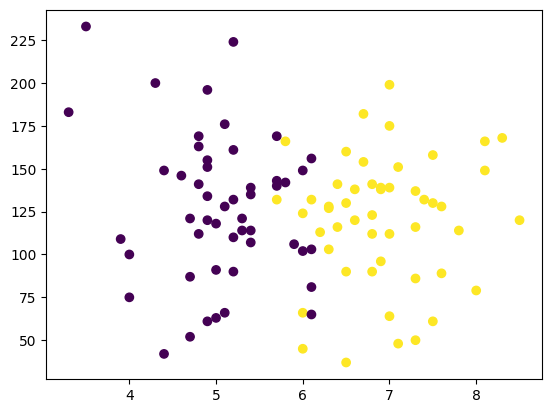

In [120]:
# plot between cgpa and ip and also color with who os placed so yellow is placed
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

### extracted i/p and o/p columns

In [121]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [122]:
X.head()

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [123]:
y.head()

,placement
0,1
1,0
2,0
3,1
4,0


### train and test split

In [124]:
# spliting data into train and test and saving into X_train,y_train
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1)

In [125]:
X_train

,cgpa,iq
99,6.2,113.0
69,8.5,120.0
34,4.8,163.0
10,6.0,45.0
63,6.3,128.0
...,...,...
32,7.0,139.0
49,5.4,135.0
85,5.8,166.0
61,7.3,137.0


In [126]:
X_test

,cgpa,iq
50,3.5,233.0
84,5.7,169.0
15,5.1,176.0
46,5.3,114.0
33,6.0,149.0
17,3.3,183.0
42,7.6,89.0
60,6.9,139.0
30,7.6,128.0
55,7.8,114.0


### sacling the data

In [127]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [128]:
X_train = scaler.fit_transform(X_train)

In [129]:
X_train

array([[ 0.18174161, -0.19938048],
       [ 2.30719433, -0.01838667],
       [-1.11201222,  1.09343242],
       [-0.00308037, -1.95760602],
       [ 0.2741526 ,  0.18846339],
       [ 0.82861852,  0.44702597],
       [ 0.73620754,  0.0591821 ],
       [-1.2968342 ,  0.65387604],
       [ 0.73620754, -0.22523674],
       [-0.28031333,  0.57630726],
       [-0.00308037, -1.41462461],
       [ 0.08933062, -1.02678074],
       [ 1.38308445, -1.5439059 ],
       [-1.20442321, -1.77661222],
       [ 0.08933062, -1.44048086],
       [ 0.92102951, -1.46633712],
       [-0.64995728,  0.00746959],
       [ 1.19826248, -0.1218117 ],
       [-1.48165617,  0.73144481],
       [ 0.2741526 ,  0.16260713],
       [-1.01960123,  0.88658236],
       [-1.11201222,  0.52459475],
       [ 1.38308445,  0.96415113],
       [-1.01960123, -1.5439059 ],
       [-0.74236827,  1.04171991],
       [ 1.29067346,  0.29188842],
       [-0.92719025, -0.07009919],
       [-0.74236827, -0.79407441],
       [ 1.93755038,

In [130]:
X_test = scaler.fit_transform(X_test)

In [131]:
X_test

array([[-1.53769359,  2.09456063],
       [-0.11629615,  0.49106924],
       [-0.50395   ,  0.66645111],
       [-0.37473205, -0.88693118],
       [ 0.07753077, -0.01002182],
       [-1.66691154,  0.84183298],
       [ 1.11127436, -1.513295  ],
       [ 0.65901154, -0.26056735],
       [ 1.11127436, -0.53616744],
       [ 1.24049231, -0.88693118]])

### training the model

In [132]:
from sklearn.linear_model import LogisticRegression

In [133]:
clf = LogisticRegression()

In [134]:
clf.fit(X_train,y_train)

LogisticRegression()

### evaluate the model


In [137]:
y_pred = clf.predict(X_test)

In [136]:
y_test

,placement
50,0
84,0
15,0
46,0
33,0
17,0
42,1
60,1
30,1
55,1


### accuracy finding

In [138]:
from sklearn.metrics import accuracy_score

In [139]:
accuracy_score(y_test,y_pred)

0.9

### making the decison boundry

In [140]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

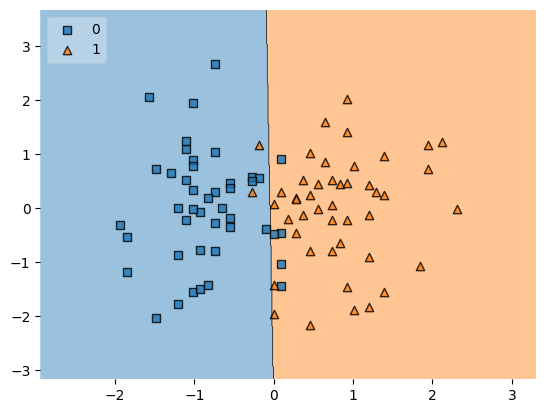

In [141]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

### deploy the model

In [143]:
import pickle

In [145]:
pickle.dump(clf,open('model.pkl','wb'))